In [50]:
from RamanModel import generateCurve
from AdaptiveKnn import *
from HelperFunctions import *
import matplotlib.pyplot as plt

In [87]:
import numpy as np
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter

ref_params = {
    "center_range": (0.1, 0.9),
    "amplitude_range": (0.01, 1.0),
    "gamma_range": (0.003, 0.05),
    "x_min": 0,
    "x_max": 1
 }


x, y, params = generateCurve(ref_params, 4, 1000, 0.1)
y_filtered = savgol_filter(y, window_length=21, polyorder=3)

In [88]:
noise = calc_noise(y)
noise

np.float64(0.12273412571571124)

In [89]:
def knnFit_persistentV2(samples, base_parameters, target_x, target_y, noise, num_peaks=4, k=10, rounds=3, eps=0.15):
    peak_search_spaces = []
    
    for _ in range(num_peaks):
        peak_search_spaces.append({
            "center_range": list(base_parameters["center_range"]),
            "amplitude_range": list(base_parameters["amplitude_range"]),
            "gamma_range": list(base_parameters["gamma_range"])
        })

    # MOVE HEAP OUTSIDE THE ROUNDS LOOP
    heap = []
    best_neighbor_params = []

    # DEFINE X RANGE FOR PROB MAP SAMPLING
    x_range = np.linspace(0, 1, len(target_y))

    # CALCULATE PROBABILITY MAP FOR FIRST PASS
    probs = create_probability_map(target_y, num_peaks=num_peaks, resolution=50)
    first_round_centers = np.empty((samples, num_peaks))
    preallocate_centers(first_round_centers, samples, num_peaks, probs, x_range)

    #######################################################
    ##################### Nth PASS ########################
    #######################################################
    
    for r in range(rounds):
        current_y = np.empty_like(target_x)
        
        # INITIALIZE PARAMETERS
        centers = np.empty((samples, num_peaks))
        amps    = np.empty((samples, num_peaks))
        gammas  = np.empty((samples, num_peaks))

        for i in range(num_peaks):
            p = peak_search_spaces[i]
        
            # 1. Determine Centers First
            if r == 0:
                centers[:, i] = first_round_centers[:, i]
            else:
                centers[:, i] = np.random.uniform(
                    p["center_range"][0],
                    p["center_range"][1],
                    size=samples
                )
        
            # 2. Determine Amplitudes based on Center Intensities and Noise
            # Map physical center positions to integer array indices of target_y
            center_indices = np.searchsorted(target_x, centers[:, i])
            center_indices = np.clip(center_indices, 0, len(target_y) - 1)
            
            # Fetch local y-values at chosen centers
            y_at_centers = target_y[center_indices]
            
            # Calculate dynamic lower and upper amplitude bounds
            min_amp_bound = p["amplitude_range"][0]
            max_amp_bound = p["amplitude_range"][1]
            
            lower_bounds = np.maximum(y_at_centers - noise, min_amp_bound)
            upper_bounds = np.minimum(y_at_centers + noise, max_amp_bound)
            
            # Ensure lower_bounds <= upper_bounds to prevent invalid uniform range sampling
            upper_bounds = np.maximum(lower_bounds, upper_bounds)
            
            amps[:, i] = np.random.uniform(
                lower_bounds,
                upper_bounds,
                size=samples
            )
        
            # 3. Determine Gammas
            gammas[:, i] = np.random.uniform(
                p["gamma_range"][0],
                p["gamma_range"][1],
                size=samples
            )

        # START LOOP
        for sample_idx in range(samples):
            current_y.fill(0.0)
            current_params = []

            for i in range(num_peaks):
                c = centers[sample_idx, i]
                a = amps[sample_idx, i]
                g = gammas[sample_idx, i]

                add_lorentzian(current_y, target_x, c, g, a)
                current_params.append({"center": c, "amplitude": a, "gamma": g})

            normalize_curve(current_y)

            dist = euclidean_distance(target_y, current_y)

            if len(heap) < k:
                heapq.heappush(heap, (-dist, sample_idx, current_params))
            else:
                if -dist > heap[0][0]:
                    heapq.heapreplace(heap, (-dist, sample_idx, current_params))
                    
        # --- Clustering Peaks ---
        nearest_neighbors = [item[2] for item in heap]

        all_candidate_peaks = []
        for neighbor_id, neighbor_params in enumerate(nearest_neighbors):
            for peak in neighbor_params:
                all_candidate_peaks.append({
                    "data": peak,
                    "origin_curve": neighbor_id
                })

        visited = [False] * len(all_candidate_peaks)
        valid_clusters = []

        for i in range(len(all_candidate_peaks)):
            if visited[i]: continue

            cluster_indices = [i]
            curves_in_cluster = {all_candidate_peaks[i]["origin_curve"]}

            for j in range(len(all_candidate_peaks)):
                if i == j: continue

                dist = get_param_distance(
                    all_candidate_peaks[i]["data"],
                    all_candidate_peaks[j]["data"],
                    base_parameters
                )

                if dist < eps:
                    cluster_indices.append(j)
                    curves_in_cluster.add(all_candidate_peaks[j]["origin_curve"])

            if len(curves_in_cluster) > (k // 2):
                valid_clusters.append(cluster_indices)
                for idx in cluster_indices:
                    visited[idx] = True

        # Sort and update search spaces
        valid_clusters.sort(key=lambda c_idx: np.mean([all_candidate_peaks[idx]['data']['center'] for idx in c_idx]))

        for p_idx, cluster_indices in enumerate(valid_clusters[:num_peaks]):
            c_vals = [all_candidate_peaks[i]['data']['center'] for i in cluster_indices]
            a_vals = [all_candidate_peaks[i]['data']['amplitude'] for i in cluster_indices]
            g_vals = [all_candidate_peaks[i]['data']['gamma'] for i in cluster_indices]

            peak_search_spaces[p_idx]["center_range"] = [min(c_vals), max(c_vals)]
            peak_search_spaces[p_idx]["amplitude_range"] = [min(a_vals), max(a_vals)]
            peak_search_spaces[p_idx]["gamma_range"] = [min(g_vals), max(g_vals)]

        best_neighbor_params = max(heap, key=lambda x: x[0])[2]

    return nearest_neighbors

In [90]:
import numpy as np
import matplotlib.pyplot as plt

def plot_knn_fits(target_x, target_y, nearest_neighbors, normalize=True):
    """
    Plots the original target spectrum alongside all reconstructed k-nearest neighbor curves.
    
    Parameters:
    - target_x: 1D array of x-coordinates (wavenumbers/wavelengths).
    - target_y: 1D array of y-coordinates (intensities).
    - nearest_neighbors: List of peak parameter dictionaries returned by knnFit_persistentV2.
    - normalize: If True, normalizes target_y to match the normalized synthetic spectra scale.
    """
    plt.figure(figsize=(10, 6), dpi=120)
    
    # Pre-process target spectrum if needed for alignment
    y_plot = np.copy(target_y)
    if normalize:
        normalize_curve(y_plot)  # Uses your existing normalization function

    # 1. Plot individual nearest neighbor fitted curves
    for idx, neighbor_params in enumerate(nearest_neighbors):
        synth_y = np.zeros_like(target_x)
        for peak in neighbor_params:
            add_lorentzian(
                synth_y, 
                target_x, 
                peak["center"], 
                peak["gamma"], 
                peak["amplitude"]
            )
        normalize_curve(synth_y)
        
        plt.plot(
            target_x, 
            synth_y, 
            color='tab:cyan', 
            alpha=0.75, 
            linewidth=1.2,
            label='KNN Neighbors' if idx == 0 else "" # Avoid duplicate legend entries
        )

    # 2. Plot Target Spectrum on top
    plt.plot(
        target_x, 
        y_plot, 
        color='black', 
        linewidth=1.0,
        alpha=0.5,
        label='Target Spectrum'
    )

    plt.xlabel('X (e.g., Raman Shift cm⁻¹)')
    plt.ylabel('Normalized Intensity')
    plt.title('KNN Candidate Approximations vs. Target Spectrum')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

# --- Example Usage ---
# nearest_neighbors = knnFit_persistentV2(
#     samples=1000, base_parameters=base_params, target_x=x, target_y=y, noise=0.05
# )
# plot_knn_fits(x, y, nearest_neighbors)

0.0786472000181675


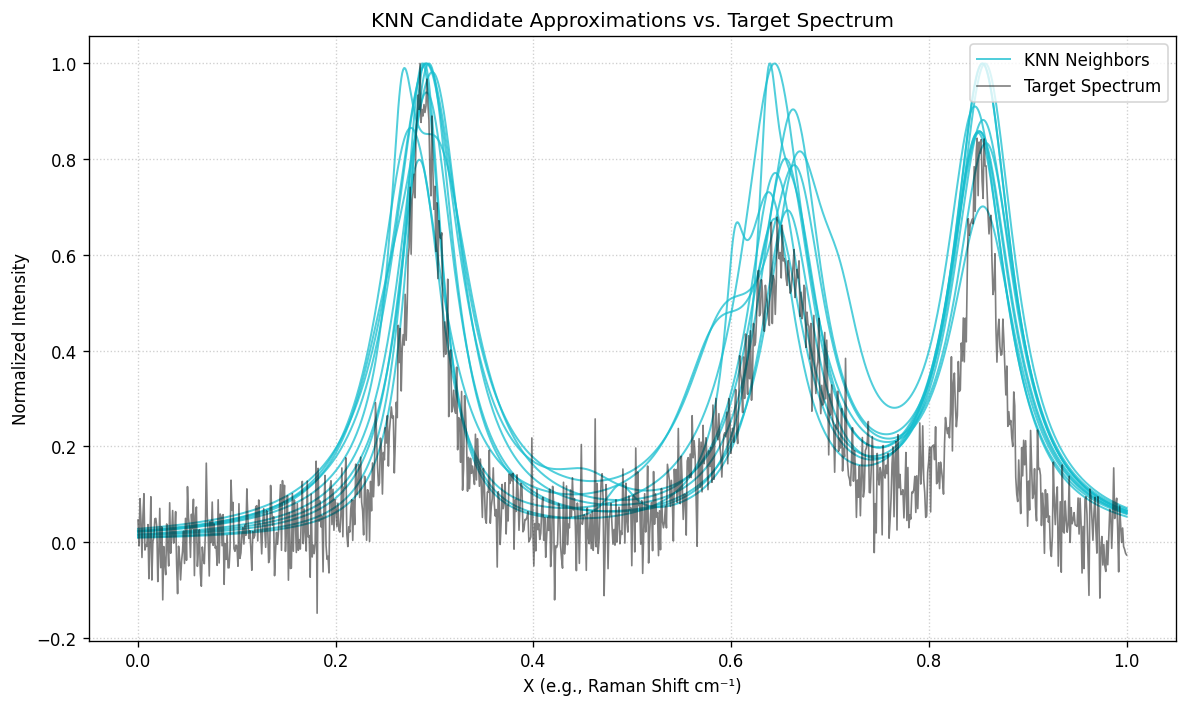

In [91]:
import time

start_time = time.perf_counter()
nearest_neighbors = knnFit_persistentV2(samples=1000, base_parameters=ref_params, target_x=x, target_y=y_filtered, num_peaks=4, noise=noise)
end_time = time.perf_counter()

print(end_time - start_time)
plot_knn_fits(x, y, nearest_neighbors)

0.06223769998177886


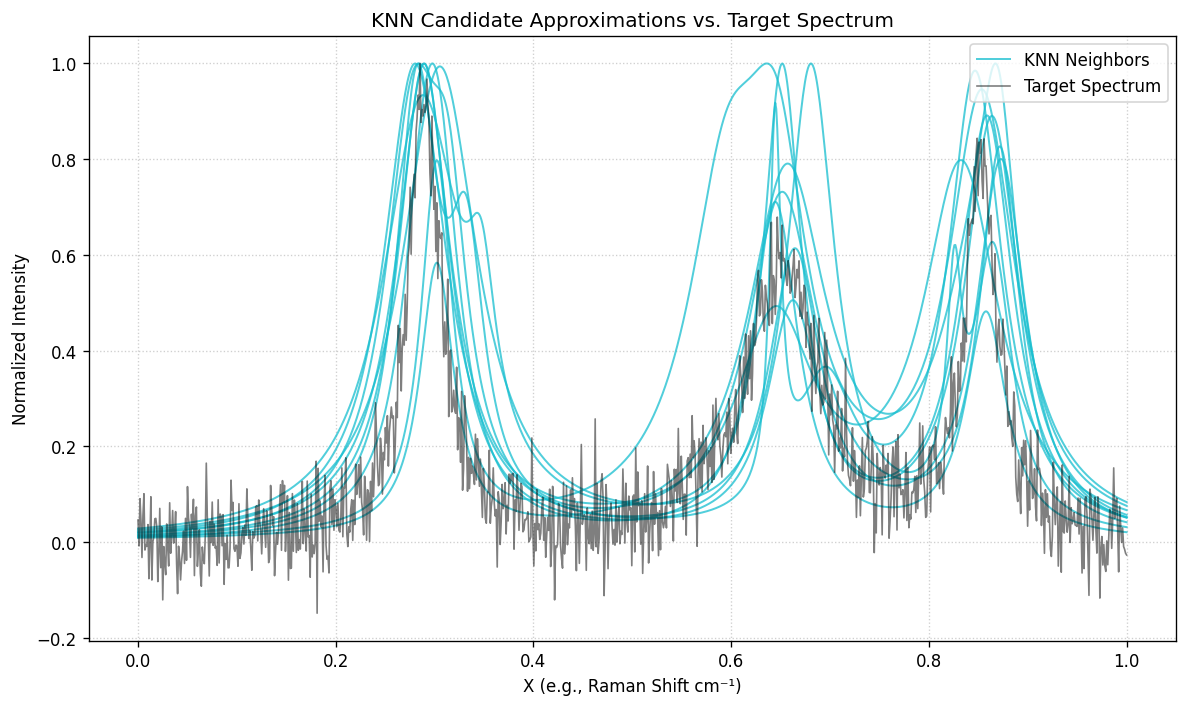

In [92]:
start_time = time.perf_counter()
nearest_neighbors = knnFit_persistent(samples=1000, base_parameters=ref_params, target_x=x, target_y=y, num_peaks=4)
end_time = time.perf_counter()

print(end_time - start_time)
plot_knn_fits(x, y, nearest_neighbors)